# Recurrent Neural Networks: Theory and Variants

## Motivation

Most Earth science data arrives as sequences: daily precipitation and streamflow, hourly wind speed, sea surface temperature anomalies evolving over months. A standard MLP treats each input independently — it has no notion of *time*. Recurrent Neural Networks (RNNs) are built specifically for sequential data: each step of the network receives the current input **and** a summary of everything seen so far, captured in a **hidden state**.

## What we'll cover

1. The vanilla RNN — math, unrolled computation graph, and limitations
2. Backpropagation through time (BPTT) and the vanishing gradient problem
3. The Long Short-Term Memory (LSTM) — forget/input/output gates and the cell state
4. The Gated Recurrent Unit (GRU) — a streamlined alternative
5. Summary table and Earth science connections

## Earth science connection

Rainfall-runoff modeling, seasonal climate forecasting, and anomaly detection in sensor networks all involve learning long-range dependencies in time series — exactly what LSTMs were designed for.

Additionally, you may wish to consult this repo for further walkthrough: https://github.com/BennettHydroLab/zero_to_lstm/tree/main

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn

rng = np.random.default_rng(42)

## 1. The Vanilla RNN

### Formulation

At each time step $t$, the RNN maintains a hidden state $\mathbf{h}_t \in \mathbb{R}^H$ and receives an input $\mathbf{x}_t \in \mathbb{R}^D$. The update rule is:

$$
\mathbf{h}_t = \tanh\!\left(W_{hh}\,\mathbf{h}_{t-1} + W_{xh}\,\mathbf{x}_t + \mathbf{b}_h\right)
$$

$$
\mathbf{y}_t = W_{hy}\,\mathbf{h}_t + \mathbf{b}_y
$$

where $W_{hh} \in \mathbb{R}^{H \times H}$, $W_{xh} \in \mathbb{R}^{H \times D}$, and $W_{hy} \in \mathbb{R}^{O \times H}$.

**Key insight:** the *same* weight matrices are applied at every time step. The hidden state $\mathbf{h}_t$ is the RNN's memory — it summarizes the sequence $\mathbf{x}_1, \ldots, \mathbf{x}_t$.

### Unrolled computation graph

We can "unroll" the RNN across time, making it look like a very deep feedforward network where each layer corresponds to one time step:

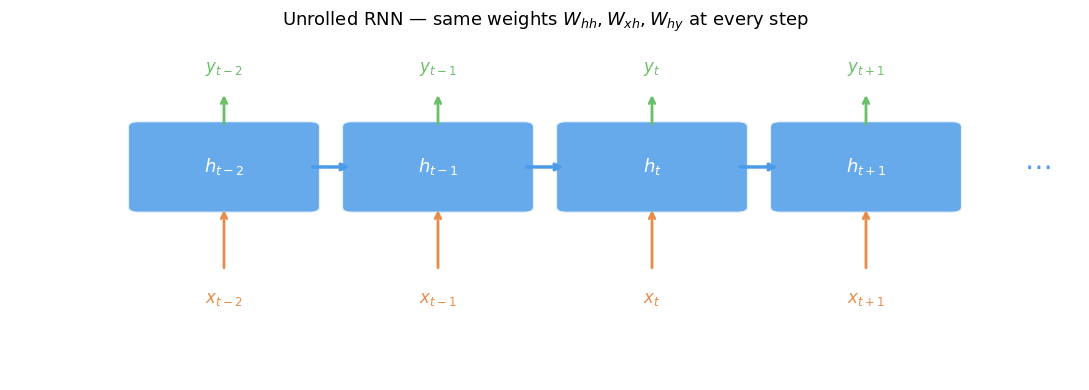

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')

# Plain strings used as LaTeX subscript content (no dollar signs here)
steps = ['t-2', 't-1', 't', 't+1']
colors = {'h': '#4c9be8', 'x': '#e88c4c', 'y': '#6abf69'}

for i, label in enumerate(steps):
    # Hidden state box
    hbox = mpatches.FancyBboxPatch((i + 0.1, 1.0), 0.8, 0.7,
                                    boxstyle='round,pad=0.05',
                                    facecolor=colors['h'], alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(hbox)
    ax.text(i + 0.5, 1.35, f'$h_{{{label}}}$', ha='center', va='center',
            fontsize=13, color='white', fontweight='bold')

    # Input arrow
    ax.annotate('', xy=(i + 0.5, 1.0), xytext=(i + 0.5, 0.45),
                arrowprops=dict(arrowstyle='->', color=colors['x'], lw=2))
    ax.text(i + 0.5, 0.2, f'$x_{{{label}}}$', ha='center', va='center',
            fontsize=12, color=colors['x'], fontweight='bold')

    # Output arrow
    ax.annotate('', xy=(i + 0.5, 2.0), xytext=(i + 0.5, 1.7),
                arrowprops=dict(arrowstyle='->', color=colors['y'], lw=2))
    ax.text(i + 0.5, 2.2, f'$y_{{{label}}}$', ha='center', va='center',
            fontsize=12, color=colors['y'], fontweight='bold')

    # Horizontal hidden-state arrow (right)
    if i < len(steps) - 1:
        ax.annotate('', xy=(i + 1.1, 1.35), xytext=(i + 0.9, 1.35),
                    arrowprops=dict(arrowstyle='->', color=colors['h'], lw=2.5))

ax.text(4.3, 1.35, r'$\cdots$', ha='center', va='center', fontsize=20, color=colors['h'])
ax.set_title(r'Unrolled RNN — same weights $W_{hh}, W_{xh}, W_{hy}$ at every step', fontsize=13)

plt.tight_layout()
plt.show()

### A minimal NumPy RNN

Let's implement one forward pass by hand to make the equations concrete.

In [3]:
class VanillaRNN:
    """Single-layer RNN with tanh activation, implemented in NumPy."""
    def __init__(self, input_size, hidden_size, output_size):
        scale = 0.1
        self.Wxh = rng.standard_normal((hidden_size, input_size))  * scale
        self.Whh = rng.standard_normal((hidden_size, hidden_size)) * scale
        self.Why = rng.standard_normal((output_size, hidden_size)) * scale
        self.bh  = np.zeros(hidden_size)
        self.by  = np.zeros(output_size)

    def forward(self, xs):
        """xs: list of input vectors (each shape [D]). Returns list of outputs and hidden states."""
        h = np.zeros(self.Whh.shape[0])
        hs, ys = [], []
        for x in xs:
            h = np.tanh(self.Wxh @ x + self.Whh @ h + self.bh)
            y = self.Why @ h + self.by
            hs.append(h.copy())
            ys.append(y.copy())
        return ys, hs

# Demo: feed a 10-step sequence of random 3-D inputs
rnn = VanillaRNN(input_size=3, hidden_size=8, output_size=1)
xs = [rng.standard_normal(3) for _ in range(10)]
ys, hs = rnn.forward(xs)

print(f"Output at each step: {[f'{y[0]:.4f}' for y in ys]}")
print(f"Hidden state shape at last step: {hs[-1].shape}")

Output at each step: ['0.0351', '0.0090', '-0.0281', '0.0338', '0.0628', '0.0179', '0.0144', '-0.0608', '-0.0035', '-0.0288']
Hidden state shape at last step: (8,)


## 2. Backpropagation Through Time and the Vanishing Gradient Problem

### BPTT

To train an RNN we unroll it across $T$ time steps and apply standard backpropagation. The gradient of the loss $\mathcal{L}$ with respect to an early hidden state $\mathbf{h}_k$ involves a product of Jacobians:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{h}_k} = \frac{\partial \mathcal{L}}{\partial \mathbf{h}_T} \prod_{t=k+1}^{T} \frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-1}}
$$

Each factor is:

$$
\frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-1}} = \text{diag}\!\left(1 - \mathbf{h}_t^2\right) W_{hh}
$$

If the largest singular value of $W_{hh}$ is $< 1$ (or the $\tanh$ saturates), this product **shrinks exponentially** with $T-k$  — the **vanishing gradient problem**.  
If it is $> 1$, gradients **explode** (partially addressed by gradient clipping).


## 3. The Long Short-Term Memory (LSTM)

Hochreiter & Schmidhuber (1997) introduced the LSTM to solve the vanishing gradient problem. The key innovation is a **cell state** $\mathbf{c}_t$ — a "conveyor belt" that carries information across time with only multiplicative interactions, rather than additive ones involving $\tanh$.

### Gates

Three sigmoid gates control what the cell state remembers, accepts, and outputs:

| Gate | Symbol | Role |
|------|--------|------|
| Forget | $\mathbf{f}_t$ | What fraction of $\mathbf{c}_{t-1}$ to keep |
| Input  | $\mathbf{i}_t$ | What new information to write |
| Output | $\mathbf{o}_t$ | What part of the cell state to expose as $\mathbf{h}_t$ |

### Full LSTM equations

Given input $\mathbf{x}_t$, previous hidden state $\mathbf{h}_{t-1}$, and previous cell state $\mathbf{c}_{t-1}$:

$$
\mathbf{f}_t = \sigma\!\left(W_f [\mathbf{h}_{t-1},\, \mathbf{x}_t] + \mathbf{b}_f\right) \quad \text{(forget gate)}
$$

$$
\mathbf{i}_t = \sigma\!\left(W_i [\mathbf{h}_{t-1},\, \mathbf{x}_t] + \mathbf{b}_i\right) \quad \text{(input gate)}
$$

$$
\tilde{\mathbf{c}}_t = \tanh\!\left(W_c [\mathbf{h}_{t-1},\, \mathbf{x}_t] + \mathbf{b}_c\right) \quad \text{(candidate cell)}
$$

$$
\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t \quad \text{(cell state update)}
$$

$$
\mathbf{o}_t = \sigma\!\left(W_o [\mathbf{h}_{t-1},\, \mathbf{x}_t] + \mathbf{b}_o\right) \quad \text{(output gate)}
$$

$$
\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t) \quad \text{(hidden state)}
$$

where $\odot$ is element-wise multiplication and $[\mathbf{h}_{t-1}, \mathbf{x}_t]$ denotes concatenation.

### Why does this help?

The cell state update $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \ldots$ is an **additive** operation. Gradients flowing back through it only pass through the element-wise multiply by $\mathbf{f}_t$, rather than through a full matrix multiply and $\tanh$. If the forget gate is near 1, the cell state — and the gradient — passes through essentially unchanged.

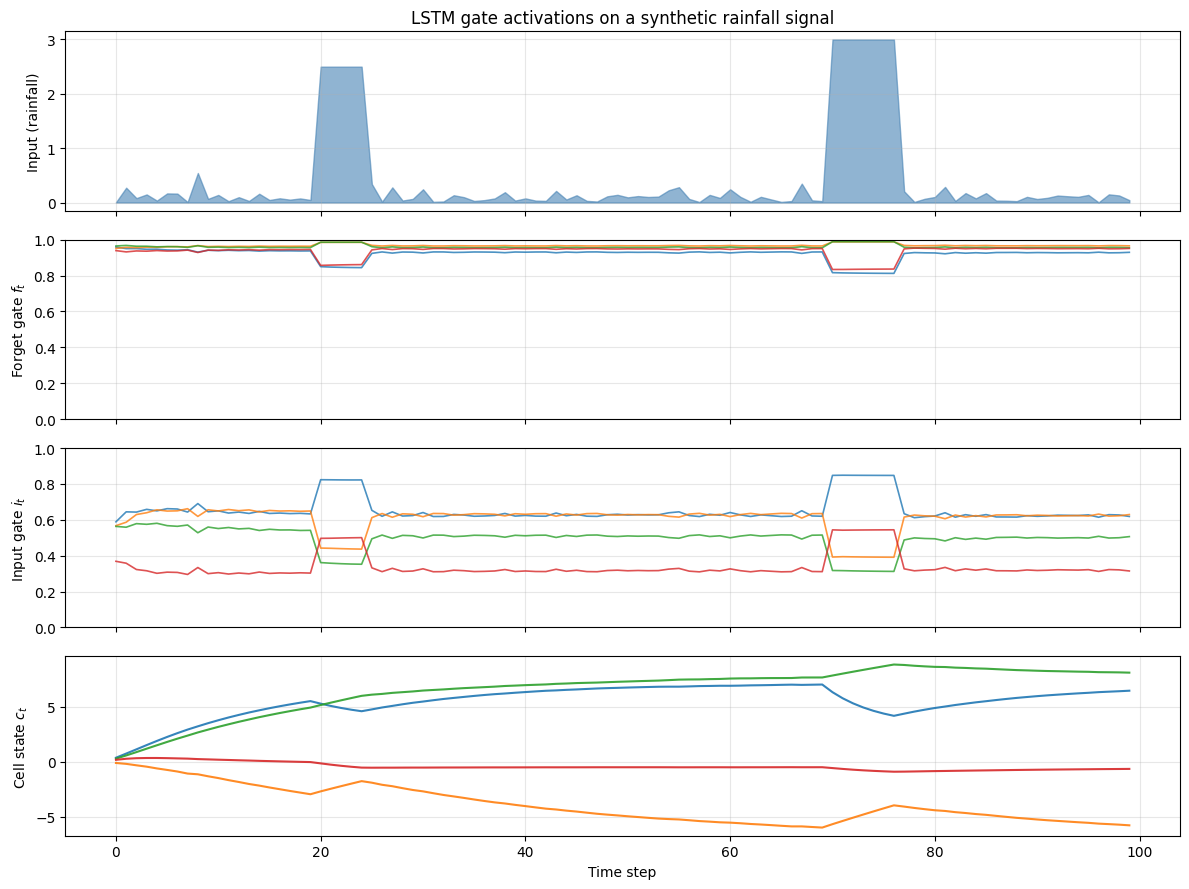

In [5]:
# Visualise the LSTM gating mechanism on a synthetic signal
# We'll pass a synthetic rainfall time series through a pre-initialized LSTM
# and inspect the gate activations

T_demo = 100
# Synthetic: mostly dry periods with two heavy rain events
x_demo = rng.exponential(0.1, (1, T_demo, 1)).astype(np.float32)
x_demo[0, 20:25, 0] = 2.5  # first storm
x_demo[0, 70:77, 0] = 3.0  # second storm

lstm_demo = nn.LSTM(input_size=1, hidden_size=4, batch_first=True)
# Bias forget gate strongly positive so cell remembers by default
with torch.no_grad():
    lstm_demo.bias_hh_l0[4:8] = 3.0  # forget gate biases

x_t = torch.tensor(x_demo)
with torch.no_grad():
    output, (hn, cn) = lstm_demo(x_t)

# Manually extract gate activations step by step
h = torch.zeros(1, 1, 4)
c = torch.zeros(1, 1, 4)
forget_gates, input_gates, output_gates, cell_states = [], [], [], []

with torch.no_grad():
    for t in range(T_demo):
        x_step = x_t[:, t:t+1, :]
        out, (h, c) = lstm_demo(x_step, (h, c))
        # gates = W_ih @ x + b_ih + W_hh @ h + b_hh  (all 4*H)
        gates = (lstm_demo.weight_ih_l0 @ x_step[0, 0] +
                 lstm_demo.bias_ih_l0 +
                 lstm_demo.weight_hh_l0 @ h[0, 0] +
                 lstm_demo.bias_hh_l0)
        H = 4
        i_g = torch.sigmoid(gates[:H]).numpy()
        f_g = torch.sigmoid(gates[H:2*H]).numpy()
        o_g = torch.sigmoid(gates[2*H:3*H]).numpy()
        forget_gates.append(f_g)
        input_gates.append(i_g)
        output_gates.append(o_g)
        cell_states.append(c[0, 0].numpy().copy())

forget_gates = np.array(forget_gates)  # (T, H)
input_gates  = np.array(input_gates)
cell_states  = np.array(cell_states)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].fill_between(range(T_demo), x_demo[0, :, 0], alpha=0.6, color='steelblue')
axes[0].set_ylabel('Input (rainfall)')
axes[0].set_title('LSTM gate activations on a synthetic rainfall signal')
axes[0].grid(alpha=0.3)

axes[1].plot(forget_gates, lw=1.2, alpha=0.8)
axes[1].set_ylabel('Forget gate $f_t$')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

axes[2].plot(input_gates, lw=1.2, alpha=0.8)
axes[2].set_ylabel('Input gate $i_t$')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

axes[3].plot(cell_states, lw=1.5, alpha=0.9)
axes[3].set_ylabel('Cell state $c_t$')
axes[3].set_xlabel('Time step')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. The Gated Recurrent Unit (GRU)

Cho et al. (2014) proposed the GRU as a simpler alternative to the LSTM. It merges the cell state and hidden state into one, and uses only **two gates**:

| Gate | Symbol | Role |
|------|--------|------|
| Reset | $\mathbf{r}_t$ | How much of the past hidden state to use when forming the candidate |
| Update | $\mathbf{z}_t$ | How much to interpolate between old hidden state and new candidate |

### GRU equations

$$
\mathbf{r}_t = \sigma\!\left(W_r [\mathbf{h}_{t-1},\, \mathbf{x}_t]\right) \quad \text{(reset gate)}
$$

$$
\mathbf{z}_t = \sigma\!\left(W_z [\mathbf{h}_{t-1},\, \mathbf{x}_t]\right) \quad \text{(update gate)}
$$

$$
\tilde{\mathbf{h}}_t = \tanh\!\left(W [\mathbf{r}_t \odot \mathbf{h}_{t-1},\, \mathbf{x}_t]\right) \quad \text{(candidate hidden state)}
$$

$$
\mathbf{h}_t = (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t \quad \text{(hidden state update)}
$$

The update gate $\mathbf{z}_t$ plays the role of **both** the forget and input gates simultaneously: when $z_t \approx 0$, the old state is kept; when $z_t \approx 1$, it is replaced by the new candidate.

### LSTM vs. GRU in practice

| Feature | LSTM | GRU |
|---------|------|-----|
| Parameters (per hidden unit) | 4 weight matrices | 3 weight matrices |
| Separate cell state | Yes ($\mathbf{c}_t$) | No |
| Performance | Often slightly better on long sequences | Often comparable on shorter sequences |
| Training speed | Slower | Faster |
| When to use | Long memory tasks, e.g. multi-year hydrology | Shorter memory, limited compute |

## 5. Comparing RNN, LSTM, and GRU on a synthetic long-range memory task

We construct a task where the target is correlated with an input seen many steps earlier, not the most recent inputs. This tests each architecture's ability to capture long-range dependencies.

Training RNN...
Training GRU...
Training LSTM...


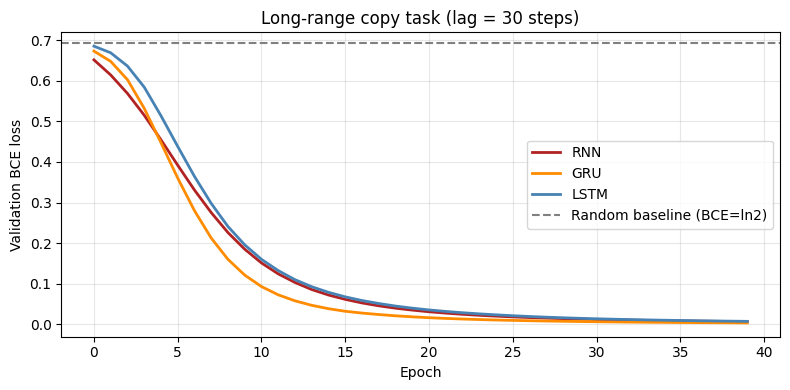

In [6]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Synthetic dataset: copy task ---
# Input: random binary sequence of length T
# Target: value from LAG steps ago
T_seq = 40
LAG   = 30  # must remember this far back
N     = 2000

torch.manual_seed(42)
X = torch.randint(0, 2, (N, T_seq, 1)).float()
Y = X[:, :T_seq - LAG, :]  # target[t] = input[t - LAG]  (shifted)
# We predict the last T_seq-LAG values: target[i] = X[i, i+LAG]
Y = X[:, LAG:, :]

split = int(0.8 * N)
train_ds = TensorDataset(X[:split], Y[:split])
val_ds   = TensorDataset(X[split:], Y[split:])
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)

def make_model(cell_type, hidden=32):
    class Model(nn.Module):
        def __init__(self):
            super().__init__()
            if cell_type == 'RNN':
                self.rnn = nn.RNN(1, hidden, batch_first=True)
            elif cell_type == 'LSTM':
                self.rnn = nn.LSTM(1, hidden, batch_first=True)
            elif cell_type == 'GRU':
                self.rnn = nn.GRU(1, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, 1)

        def forward(self, x):
            if cell_type == 'LSTM':
                o, _ = self.rnn(x)
            else:
                o, _ = self.rnn(x)
            # predict lagged output: take time steps LAG: onward
            return torch.sigmoid(self.fc(o[:, LAG:, :]))
    return Model()

def train(model, n_epochs=40):
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()
    val_losses = []
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_dl:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = sum(loss_fn(model(xb), yb).item() for xb, yb in val_dl) / len(val_dl)
        val_losses.append(vl)
    return val_losses

models = {name: make_model(name) for name in ['RNN', 'GRU', 'LSTM']}
val_curves = {}
for name, m in models.items():
    print(f"Training {name}...")
    val_curves[name] = train(m)

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'RNN': 'firebrick', 'GRU': 'darkorange', 'LSTM': 'steelblue'}
for name, curve in val_curves.items():
    ax.plot(curve, label=name, color=colors[name], lw=2)
ax.axhline(np.log(2), color='gray', linestyle='--', label='Random baseline (BCE=ln2)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BCE loss')
ax.set_title(f'Long-range copy task (lag = {LAG} steps)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

| Concept | Key idea |
|---------|----------|
| **Vanilla RNN** | Hidden state $\mathbf{h}_t = \tanh(W_{hh}\mathbf{h}_{t-1} + W_{xh}\mathbf{x}_t)$ — same weights, every step |
| **BPTT** | Unroll and backprop; gradients involve products of Jacobians over $T$ steps |
| **Vanishing gradient** | Product of Jacobians → 0 exponentially fast; RNN forgets distant past |
| **LSTM** | Cell state $\mathbf{c}_t$ carries information through additive updates; three gates control read/write/forget |
| **GRU** | Simplified LSTM with two gates (reset, update); no separate cell state |
| **Gradient flow** | LSTM/GRU allow near-constant gradient flow through the cell/hidden state highway |

### Looking Ahead

In the next notebook we apply an LSTM to the Leaf River catchment: we'll use a lagged lookback window of daily precipitation and temperature to predict streamflow, and evaluate using hydrologically-meaningful metrics (NSE, RMSE, percent bias). This is the same general architecture used in the landmark **Entity-Aware LSTM (EA-LSTM)** and **Neural Hydrology** models that outperform traditional conceptual models across thousands of catchments.